# Main

## Data

### Read Data

In [2]:
import pandas as pd

In [3]:
url = "https://raw.githubusercontent.com/deristnoor/python/refs/heads/master/project/Data%20Science%20%26%20Machine%20Learning/Melting%20Points/data/train.csv"
df = pd.read_csv(url, index_col="id")
df.head()

,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
id,,,,,,,,,,,,,,,,,,,,,
2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### EDA

In [4]:
df.index.value_counts().sort_values(ascending=False)

id
2175    1
1222    1
2994    1
1704    1
2526    1
       ..
707     1
1573    1
1634    1
3022    1
1673    1
Name: count, Length: 2662, dtype: int64

In [5]:
df.describe()

,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,Group 9,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
count,2662.000000,2662.000000,2662.000000,2662.000000,2662.000000,2662.000000,2662.000000,2662.000000,2662.000000,2662.000000,...,2662.000000,2662.000000,2662.0,2662.000000,2662.0,2662.0,2662.0,2662.0,2662.0,2662.0
mean,278.263452,1.020661,1.582269,0.114951,0.036439,0.036814,0.022915,0.013524,0.010143,0.007137,...,0.001127,0.000751,0.0,0.001878,0.0,0.0,0.0,0.0,0.0,0.0
std,85.117914,1.353640,3.738416,0.425964,0.208307,0.205516,0.164037,0.118732,0.117480,0.092695,...,0.033558,0.027405,0.0,0.058126,0.0,0.0,0.0,0.0,0.0,0.0
min,53.540000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
25%,217.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
50%,277.300000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
75%,325.150000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
max,897.150000,16.000000,42.000000,6.000000,3.000000,2.000000,2.000000,2.000000,2.000000,2.000000,...,1.000000,1.000000,0.0,2.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
df.dtypes

SMILES        object
Tm           float64
Group 1        int64
Group 2        int64
Group 3        int64
              ...   
Group 420      int64
Group 421      int64
Group 422      int64
Group 423      int64
Group 424      int64
Length: 426, dtype: object

## Modeling

### Data split

In [4]:
X = df.drop(['SMILES', 'Tm'], axis=1)
X.head()

,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,Group 9,Group 10,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
id,,,,,,,,,,,,,,,,,,,,,
2175,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1222,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2994,2,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1704,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2526,2,3,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
y = df.Tm
y.head()

id
2175    213.15
1222    407.15
2994    324.15
1704    351.15
2526    126.15
Name: Tm, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    # stratify=y,
    test_size=0.2,
    random_state=0
)

### Choosing model

In [8]:
from sklearn.linear_model import LinearRegression, HuberRegressor
from xgboost.sklearn import XGBRegressor
from sklearn.metrics import mean_absolute_error

import warnings
warnings.filterwarnings('ignore')

classifiers = [
    "LinearRegression", 
    "HuberRegressor", 
    "XGBRegressor"
]

models = [
    LinearRegression(),
    HuberRegressor(), 
    XGBRegressor(random_state=0)
]

In [15]:
Score = pd.DataFrame({"Regressor":classifiers})
j = 0
mae = []
for i in models:
    model = i
    model.fit(X_train,y_train)
    predictions = model.predict(X_test)
    mae.append(mean_absolute_error(y_test,predictions))
    j = j+1     

Score["MAE"] = mae
Score.sort_values(by="MAE", ascending=False,inplace = True)
Score.reset_index(drop=True, inplace=True)
Score

,Regressor,MAE
0,LinearRegression,36.859814
1,HuberRegressor,36.626551
2,XGBRegressor,36.019691


### Search CV & parameter tuning

In [9]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [47]:
model_fix = XGBRegressor(gamma=0, min_child_weight=1, n_estimators=1200, random_state=0)

In [48]:
params = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 9],
    "subsample": [0.6, 0.7, 0.8, 0.9],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9],
    # "reg_alpha": [0, 0.1, 0.5, 1],
    # "reg_lambda": [0.5, 1, 2, 3, 4]
}

skfold = StratifiedKFold(n_splits=5)

grid_search = GridSearchCV(
    estimator=model_fix,
    param_grid=params,
    cv=5,
    scoring='neg_mean_absolute_error',
    # verbose=1,
    n_jobs=-1,
)

In [62]:
grid_search.fit(X_train, y_train)

,estimator,"XGBRegressor(...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.6, 0.7, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'subsample': [0.6, 0.7, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'reg:squarederror'


In [31]:
print('Neg_MAE_score:', grid_search.best_score_)
print('Best Parameters:', grid_search.best_params_)

Neg_MAE_score: -36.59880198763573
Best Parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 1200}


In [27]:
print('Neg_MAE_score:', grid_search.best_score_)
print('Best Parameters:', grid_search.best_params_)

Neg_MAE_score: -35.0539972119889
Best Parameters: {'gamma': 0, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 1200}


In [37]:
print('Neg_MAE_score:', grid_search.best_score_)
print('Best Parameters:', grid_search.best_params_)

Neg_MAE_score: -35.22701402165145
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 1200, 'subsample': 0.6}


In [63]:
print('Neg_MAE_score:', grid_search.best_score_)
print('Best Parameters:', grid_search.best_params_)

Neg_MAE_score: -34.52276547369653
Best Parameters: {'colsample_bytree': 0.6, 'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.9}


### Best model so far

In [64]:
model_try = XGBRegressor(
    # tree_method='hist',
    learning_rate=0.1,
    max_depth=5,
    gamma=0,
    min_child_weight=1, 
    n_estimators=1200,
    colsample_bytree=0.6,
    subsample=0.9, 
    random_state=0
)
model_try.fit(X_train, y_train)
predictions = model_try.predict(X_test)
score = mean_absolute_error(y_test,predictions)
score

33.78889115381867

## Feature Engineering for SMILES

### Derived key parameters from SMILES using RDkit

In [6]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, Descriptors, rdmolfiles, FunctionalGroups, AllChem, rdFreeSASA

In [12]:
def extract_melting_point_params(smiles_list):
    results = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            results.append({'SMILES': smi, 'error': 'Invalid SMILES'})
            continue
        
        # Intermolecular forces
        hbd = rdMolDescriptors.CalcNumHBD(mol)
        hba = rdMolDescriptors.CalcNumHBA(mol)
        tpsa = Descriptors.TPSA(mol)
        
        # Molecular symmetry estimation (simplified)
        atom_ranks = Chem.CanonicalRankAtoms(mol, breakTies=False)
        is_symmetric = len(set(atom_ranks)) < mol.GetNumAtoms()
        
        # # Functional groups (count)
        # fg_list = FunctionalGroups.GetFunctionalGroupList(mol)
        # fg_count = len(fg_list)
        
        # Molecular size & surface area
        mw = Descriptors.MolWt(mol)
        mol_with_h = Chem.AddHs(mol)
        try:
            AllChem.EmbedMolecule(mol_with_h)
            radii = rdFreeSASA.classifyAtoms(mol_with_h)
            sasa = rdFreeSASA.CalcSASA(mol_with_h, radii)
        except:
            sasa = None
        
        # Molecular shape (branching)
        degrees = [atom.GetDegree() for atom in mol.GetAtoms()]
        branching = sum([1 for d in degrees if d > 2])  # count of branching atoms
        bertz = Descriptors.BertzCT(mol)
        
        results.append({
            'SMILES': smi,
            'H_bond_donors': hbd,
            'H_bond_acceptors': hba,
            'TPSA': tpsa,
            'Is_symmetric': is_symmetric,
            # 'Functional_groups_count': fg_count,
            'Molecular_weight': mw,
            'Surface_area_SASA': sasa,
            'Branching_atoms_count': branching,
            'Bertz_complexity': bertz
        })
    return results

In [13]:
key_parameter = pd.DataFrame(extract_melting_point_params(df.SMILES))

[10:44:42] UFFTYPER: Unrecognized charge state for atom: 1
[10:44:44] UFFTYPER: Unrecognized charge state for atom: 1
[10:44:44] 

****
Pre-condition Violation
No conformers in molecule
Violation occurred on line 134 in file /private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_cc31tg3xk1/croot/rdkit_1756889094513/work/External/FreeSASA/RDFreeSASA.cpp
Failed Expression: mol.getNumConformers()
****

[10:44:47] 

****
Pre-condition Violation
No conformers in molecule
Violation occurred on line 134 in file /private/var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_cc31tg3xk1/croot/rdkit_1756889094513/work/External/FreeSASA/RDFreeSASA.cpp
Failed Expression: mol.getNumConformers()
****

[10:44:48] UFFTYPER: Unrecognized charge state for atom: 1
[10:44:48] UFFTYPER: Unrecognized charge state for atom: 2
[10:44:50] UFFTYPER: Unrecognized charge state for atom: 2
[10:44:55] UFFTYPER: Unrecognized charge state for atom: 1


In [14]:
key_parameter

,SMILES,H_bond_donors,H_bond_acceptors,TPSA,Is_symmetric,Molecular_weight,Surface_area_SASA,Branching_atoms_count,Bertz_complexity
0,FC1=C(F)C(F)(F)C1(F)F,0,0,0.00,True,162.032,123.842089,4,179.793356
1,c1ccc2c(c1)ccc3Nc4ccccc4c23,1,0,15.79,False,217.271,255.375089,6,833.661406
2,CCN1C(C)=Nc2ccccc12,0,2,17.82,False,160.220,227.674007,4,401.130826
3,CC#CC(=O)O,1,1,37.30,False,84.074,119.413843,1,104.451830
4,CCCCC(S)C,1,1,0.00,False,118.245,200.453758,1,33.161259
...,...,...,...,...,...,...,...,...,...
2657,ClCCBr,0,0,0.00,False,143.411,105.611954,0,8.000000
2658,N#CC(Cl)(Cl)Cl,0,1,23.79,True,144.388,94.602502,1,75.774438
2659,Cc1ccc2c(C)cccc2c1,0,0,0.00,False,156.228,222.787467,4,413.307866
2660,CCC(=O)c1ccc2ccccc2c1,0,1,17.07,False,184.238,244.618628,4,471.374187


### EDA Key Parameters

In [30]:
from matplotlib import pyplot as plt

Matplotlib is building the font cache; this may take a moment.


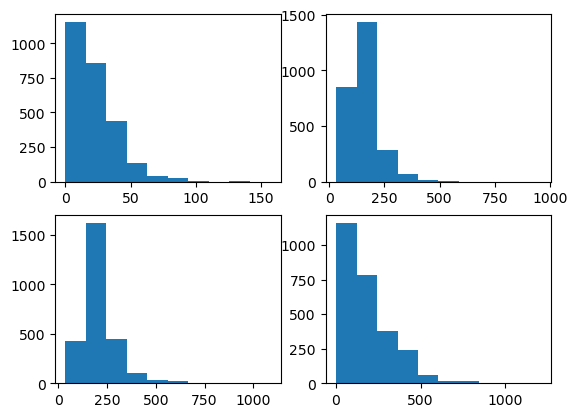

In [37]:
# Distribution of targets
fig, ax = plt.subplots(2, 2)
ax[0,0].hist(key_parameter['TPSA'])
ax[0,1].hist(key_parameter['Molecular_weight'])
ax[1,0].hist(key_parameter['Surface_area_SASA'])
ax[1,1].hist(key_parameter['Bertz_complexity'])

plt.show()

### Base Model for key parameters

In [73]:
X_key = key_parameter.drop("SMILES", axis=1)
X_key

,H_bond_donors,H_bond_acceptors,TPSA,Is_symmetric,Molecular_weight,Surface_area_SASA,Branching_atoms_count,Bertz_complexity
0,0,0,0.00,True,162.032,123.872534,4,179.793356
1,1,0,15.79,False,217.271,253.868181,6,833.661406
2,0,2,17.82,False,160.220,230.070944,4,401.130826
3,1,1,37.30,False,84.074,118.950006,1,104.451830
4,1,1,0.00,False,118.245,207.396879,1,33.161259
...,...,...,...,...,...,...,...,...
2657,0,0,0.00,False,143.411,105.846219,0,8.000000
2658,0,1,23.79,True,144.388,94.897761,1,75.774438
2659,0,0,0.00,False,156.228,224.713251,4,413.307866
2660,0,1,17.07,False,184.238,246.044274,4,471.374187


In [78]:
X_key_train, X_key_test, y_train, y_test = train_test_split(
    X_key,
    y,
    # stratify=y,
    test_size=0.2,
    random_state=0
)

In [80]:
model_key = XGBRegressor(
    # # tree_method='hist',
    learning_rate=0.1,
    max_depth=5,
    gamma=0,
    min_child_weight=1, 
    n_estimators=1200,
    colsample_bytree=0.6,
    subsample=0.9, 
    random_state=0
)
model_key.fit(X_key_train, y_train)
predictions = model_key.predict(X_key_test)
score = mean_absolute_error(y_test,predictions)
score

38.80291507971444

## Combined Feature Groups and Key Parameters Modeling

In [16]:
df

,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,...,Group 415,Group 416,Group 417,Group 418,Group 419,Group 420,Group 421,Group 422,Group 423,Group 424
id,,,,,,,,,,,,,,,,,,,,,
2175,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1222,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2994,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1704,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2526,CCCCC(S)C,126.15,2,3,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,ClCCBr,256.45,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1573,N#CC(Cl)(Cl)Cl,231.15,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1634,Cc1ccc2c(C)cccc2c1,256.25,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [15]:
key_parameter

,SMILES,H_bond_donors,H_bond_acceptors,TPSA,Is_symmetric,Molecular_weight,Surface_area_SASA,Branching_atoms_count,Bertz_complexity
0,FC1=C(F)C(F)(F)C1(F)F,0,0,0.00,True,162.032,123.842089,4,179.793356
1,c1ccc2c(c1)ccc3Nc4ccccc4c23,1,0,15.79,False,217.271,255.375089,6,833.661406
2,CCN1C(C)=Nc2ccccc12,0,2,17.82,False,160.220,227.674007,4,401.130826
3,CC#CC(=O)O,1,1,37.30,False,84.074,119.413843,1,104.451830
4,CCCCC(S)C,1,1,0.00,False,118.245,200.453758,1,33.161259
...,...,...,...,...,...,...,...,...,...
2657,ClCCBr,0,0,0.00,False,143.411,105.611954,0,8.000000
2658,N#CC(Cl)(Cl)Cl,0,1,23.79,True,144.388,94.602502,1,75.774438
2659,Cc1ccc2c(C)cccc2c1,0,0,0.00,False,156.228,222.787467,4,413.307866
2660,CCC(=O)c1ccc2ccccc2c1,0,1,17.07,False,184.238,244.618628,4,471.374187


In [22]:
combined = df.merge(key_parameter, left_on="SMILES", right_on="SMILES")
combined

,SMILES,Tm,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,...,Group 423,Group 424,H_bond_donors,H_bond_acceptors,TPSA,Is_symmetric,Molecular_weight,Surface_area_SASA,Branching_atoms_count,Bertz_complexity
0,FC1=C(F)C(F)(F)C1(F)F,213.15,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00,True,162.032,123.842089,4,179.793356
1,c1ccc2c(c1)ccc3Nc4ccccc4c23,407.15,0,0,0,0,0,0,0,0,...,0,0,1,0,15.79,False,217.271,255.375089,6,833.661406
2,CCN1C(C)=Nc2ccccc12,324.15,2,1,0,0,0,0,0,0,...,0,0,0,2,17.82,False,160.220,227.674007,4,401.130826
3,CC#CC(=O)O,351.15,1,0,0,0,0,0,0,0,...,0,0,1,1,37.30,False,84.074,119.413843,1,104.451830
4,CCCCC(S)C,126.15,2,3,0,0,0,0,0,0,...,0,0,1,1,0.00,False,118.245,200.453758,1,33.161259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,ClCCBr,256.45,0,1,0,0,0,0,0,0,...,0,0,0,0,0.00,False,143.411,105.611954,0,8.000000
2658,N#CC(Cl)(Cl)Cl,231.15,0,0,0,0,0,0,0,0,...,0,0,0,1,23.79,True,144.388,94.602502,1,75.774438
2659,Cc1ccc2c(C)cccc2c1,256.25,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00,False,156.228,222.787467,4,413.307866
2660,CCC(=O)c1ccc2ccccc2c1,333.15,1,1,0,0,0,0,0,0,...,0,0,0,1,17.07,False,184.238,244.618628,4,471.374187


In [26]:
X_com = combined.drop(["SMILES", "Tm"], axis=1)
X_com

,Group 1,Group 2,Group 3,Group 4,Group 5,Group 6,Group 7,Group 8,Group 9,Group 10,...,Group 423,Group 424,H_bond_donors,H_bond_acceptors,TPSA,Is_symmetric,Molecular_weight,Surface_area_SASA,Branching_atoms_count,Bertz_complexity
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00,True,162.032,123.842089,4,179.793356
1,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,15.79,False,217.271,255.375089,6,833.661406
2,2,1,0,0,0,0,0,0,0,0,...,0,0,0,2,17.82,False,160.220,227.674007,4,401.130826
3,1,0,0,0,0,0,0,0,0,0,...,0,0,1,1,37.30,False,84.074,119.413843,1,104.451830
4,2,3,0,0,0,0,0,0,0,0,...,0,0,1,1,0.00,False,118.245,200.453758,1,33.161259
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00,False,143.411,105.611954,0,8.000000
2658,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,23.79,True,144.388,94.602502,1,75.774438
2659,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0.00,False,156.228,222.787467,4,413.307866
2660,1,1,0,0,0,0,0,0,0,0,...,0,0,0,1,17.07,False,184.238,244.618628,4,471.374187


In [51]:
X_com_train, X_com_test, y_train, y_test = train_test_split(
    X_com,
    y,
    # stratify=y,
    test_size=0.2,
    random_state=0
)

In [29]:
model_com = XGBRegressor(
    # tree_method='hist',
    # learning_rate=0.1,
    # max_depth=5,
    # gamma=0,
    # min_child_weight=1, 
    # n_estimators=1200,
    # colsample_bytree=0.6,
    # subsample=0.9, 
    random_state=0
)
model_com.fit(X_com_train, y_train)
predictions = model_com.predict(X_com_test)
score = mean_absolute_error(y_test,predictions)
score

32.89962486052379

## Combined Feature Groups and Key Parameters with Normalisation Modeling 

In [46]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [38]:
key_parameter.columns

Index(['SMILES', 'H_bond_donors', 'H_bond_acceptors', 'TPSA', 'Is_symmetric',
       'Molecular_weight', 'Surface_area_SASA', 'Branching_atoms_count',
       'Bertz_complexity'],
      dtype='object')

In [55]:
feature_scaled = ['TPSA','Molecular_weight','Surface_area_SASA','Bertz_complexity']

In [56]:
# Separate features to normalize and others in train set
X_com_train_normalize = X_com_train[feature_scaled]
X_com_train_other = X_com_train.drop(columns=feature_scaled)

# Fit scaler on training data only
scaler = StandardScaler()
X_com_train_normalized = scaler.fit_transform(X_com_train_normalize)

# Transform test set using the same scaler
X_com_test_normalize = X_com_test[feature_scaled]
X_com_test_other = X_com_test.drop(columns=feature_scaled)
X_com_test_normalized = scaler.transform(X_com_test_normalize)

# Convert scaled arrays back to DataFrames for easier handling
X_com_train_normalized_df = pd.DataFrame(X_com_train_normalized, columns=feature_scaled, index=X_com_train.index)
X_com_test_normalized_df = pd.DataFrame(X_com_test_normalized, columns=feature_scaled, index=X_com_test.index)

# Combine normalized and non-normalized features back
X_com_train_final = pd.concat([X_com_train_other, X_com_train_normalized_df], axis=1)
X_com_test_final = pd.concat([X_com_test_other, X_com_test_normalized_df], axis=1)

In [60]:
model_norm = XGBRegressor(
    # tree_method='hist',
    learning_rate=0.1,
    max_depth=5,
    # gamma=0,
    # min_child_weight=1, 
    n_estimators=1200,
    # colsample_bytree=0.6,
    # subsample=0.9, 
    random_state=0
)
model_norm.fit(X_com_train_final, y_train)
predictions = model_norm.predict(X_com_test_final)
score = mean_absolute_error(y_test,predictions)
score

31.82676898090298